======================================================================
# Final Project Grade
======================================================================
## Graphs & Model (20 points)

* 2 univariate (5 possible)			5
* 1 multivariate (5 possible)		5
* 1 regression (5 possible)			5
* 1 profile (5 possible)				5

======================================================================
## Written interpretation (5 possible)

* significance of predictors (2.5 possible)	2.5
* interpretation of effects (2.5 possible)	2.5

======================================================================
## Visual presentation (10 possible)		10
======================================================================
## Oral presentation (5 possible)		   	5
======================================================================
## Total Score (40 possible)			40
======================================================================
## Comments: Radek! Thank you for going the extra mile to find and join a second dataset. I appreciate your consulting on your project along the way, and for your preparation in advance. I can tell you put a lot into this project. Great work!
======================================================================


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.stats import norm
import statsmodels.formula.api as smf
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
retail_path = "/content/drive/My Drive/Data science NCCU 2025/Data/Week 12 Datathon 3/Online Retail.xlsx"
gdp_path = "/content/drive/My Drive/Data science NCCU 2025/Data/Week 12 Datathon 3/GDP.xls"
output_path = "/content/drive/My Drive/Data science NCCU 2025/Data/Week 12 Datathon 3/dashboard_tables.xlsx"

In [ ]:
retail_df = pd.read_excel(retail_path)
retail_df["InvoiceDate"] = pd.to_datetime(retail_df["InvoiceDate"])
retail_df = retail_df[retail_df["InvoiceDate"].dt.year == 2011].copy()
retail_df_clean = retail_df.dropna(subset=["CustomerID", "Country", "InvoiceNo", "Quantity", "UnitPrice"]).copy()
retail_df_clean = retail_df_clean[~retail_df_clean["InvoiceNo"].astype(str).str.startswith("C")]
retail_df_clean = retail_df_clean[retail_df_clean["Quantity"] > 0]
retail_df_clean["TotalPrice"] = retail_df_clean["Quantity"] * retail_df_clean["UnitPrice"]

In [ ]:
gdp_df = pd.read_excel(gdp_path, sheet_name="Data", skiprows=3)

In [ ]:
last_column = gdp_df.columns[-1]
gdp_2011 = gdp_df[["Country Name", "2011", last_column]].rename(columns={"Country Name": "Country", "2011": "GDP_per_capita", last_column: "Population"})
gdp_2011 = gdp_2011.dropna(subset=["GDP_per_capita"])


In [ ]:
customer_spending = retail_df_clean.groupby(["Country", "CustomerID"])["TotalPrice"].sum().reset_index()
customer_counts = customer_spending.groupby("Country")["CustomerID"].nunique().reset_index()
customer_counts.columns = ["Country", "NumCustomers"]
valid_countries = customer_counts[customer_counts["NumCustomers"] >= 5]["Country"]
customer_spending = customer_spending[customer_spending["Country"].isin(valid_countries)]
avg_spending = customer_spending.groupby("Country")["TotalPrice"].mean().reset_index()

In [ ]:
invoice_counts = retail_df_clean.groupby(["Country", "CustomerID"])["InvoiceNo"].nunique().reset_index()
avg_purchases = invoice_counts.groupby("Country")["InvoiceNo"].mean().reset_index()
avg_purchases.columns = ["Country", "AvgNumPurchases"]

In [ ]:
avg_spending = pd.merge(avg_spending, customer_counts, on="Country", how="left")
avg_spending = pd.merge(avg_spending, avg_purchases, on="Country", how="left")
avg_spending.rename(columns={"TotalPrice": "AvgSpendingPerCustomer"}, inplace=True)
merged_df = pd.merge(avg_spending, gdp_2011, on="Country", how="inner")

In [ ]:
summary_stats = {
    "TotalSales_GBP": round(retail_df_clean["TotalPrice"].sum(), 2),
    "TotalCustomers": retail_df_clean["CustomerID"].nunique(),
    "TotalTransactions": retail_df_clean["InvoiceNo"].nunique(),
    "CountriesIncluded": merged_df["Country"].nunique()
}

In [ ]:
merged_df

,Country,AvgSpendingPerCustomer,NumCustomers,AvgNumPurchases,GDP_per_capita,Population
0,Australia,15276.495556,9,6.000000,62605.600458,NaN
1,Austria,992.148000,10,1.600000,51116.895352,NaN
2,Belgium,1575.457200,25,3.720000,47760.829878,NaN
3,Channel Islands,2510.863750,8,3.125000,60419.232510,NaN
4,Cyprus,1499.945000,8,1.875000,32485.796875,NaN
5,Denmark,1963.760000,9,1.888889,61809.737898,NaN
6,Finland,1804.440000,12,3.333333,51060.324259,NaN
7,France,2373.901667,84,4.380952,43929.784087,NaN
8,Germany,2297.053763,93,4.591398,47646.582043,NaN
9,Italy,1389.311667,12,3.000000,38851.388134,NaN


In [ ]:
merged_df["GDP_Tier"] = pd.qcut(merged_df["GDP_per_capita"], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])

In [ ]:
profile_df = merged_df.groupby("GDP_Tier", observed=True)["AvgSpendingPerCustomer"].mean().reset_index()

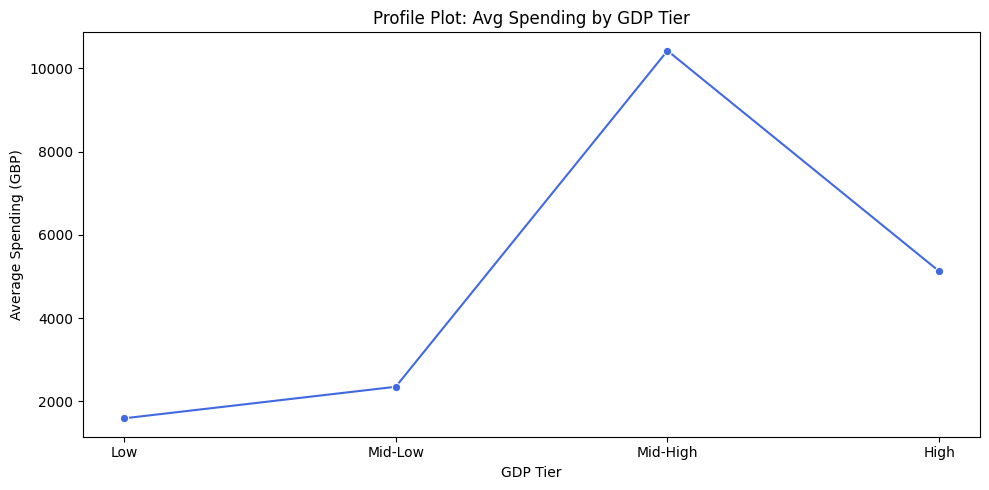

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=profile_df, x="GDP_Tier", y="AvgSpendingPerCustomer", marker="o", color="royalblue")
plt.title("Profile Plot: Avg Spending by GDP Tier")
plt.ylabel("Average Spending (GBP)")
plt.xlabel("GDP Tier")
plt.grid(False)
plt.tight_layout()
plt.show()

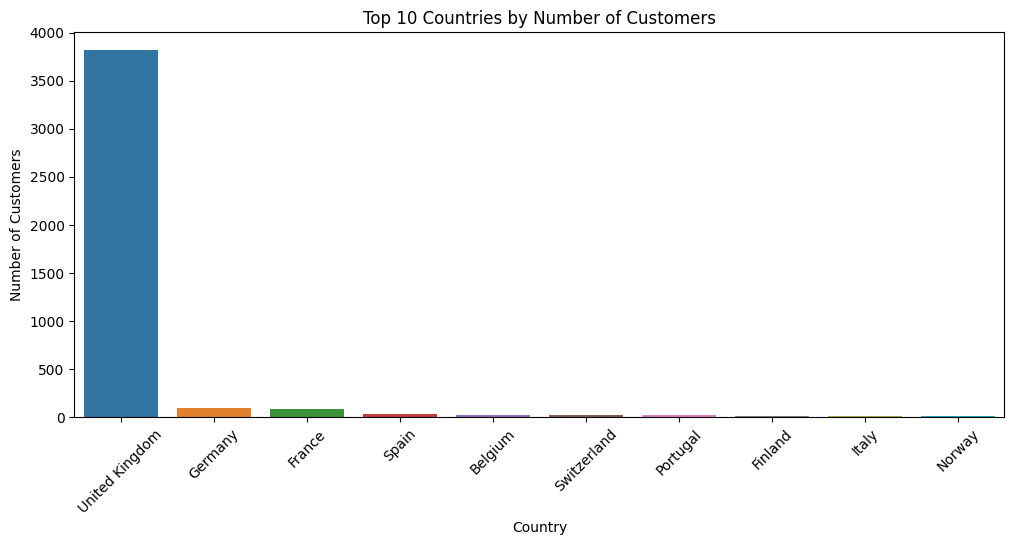

In [ ]:
top10_customers = merged_df.sort_values("NumCustomers", ascending=False).head(10)
plt.figure(figsize=(12, 5))
sns.barplot(data=top10_customers, x="Country", y="NumCustomers", hue="Country", dodge=False)
plt.title("Top 10 Countries by Number of Customers")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

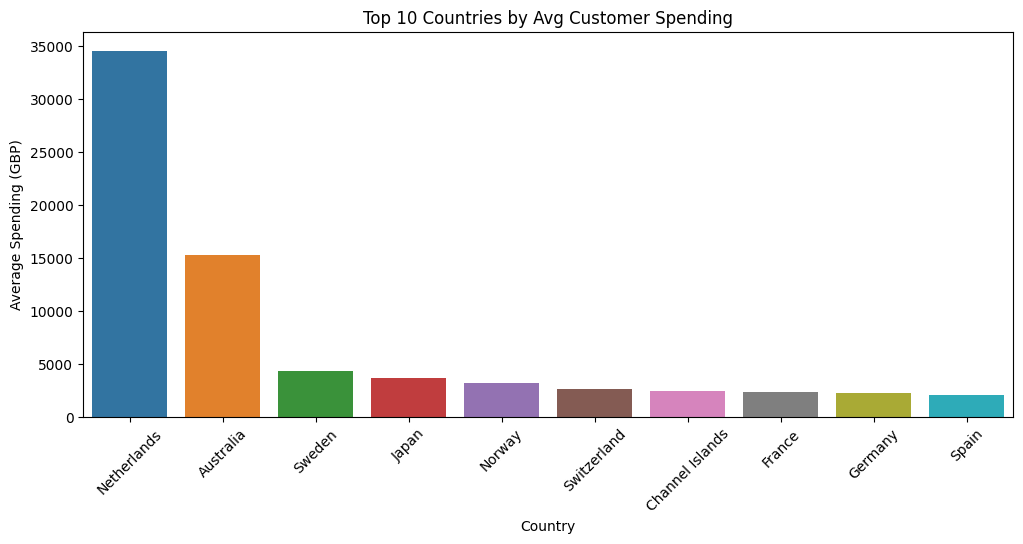

In [ ]:
top10 = merged_df.sort_values("AvgSpendingPerCustomer", ascending=False).head(10)
plt.figure(figsize=(12, 5))
sns.barplot(data=top10, x="Country", y="AvgSpendingPerCustomer", hue="Country", dodge=False)
plt.title("Top 10 Countries by Avg Customer Spending")
plt.ylabel("Average Spending (GBP)")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

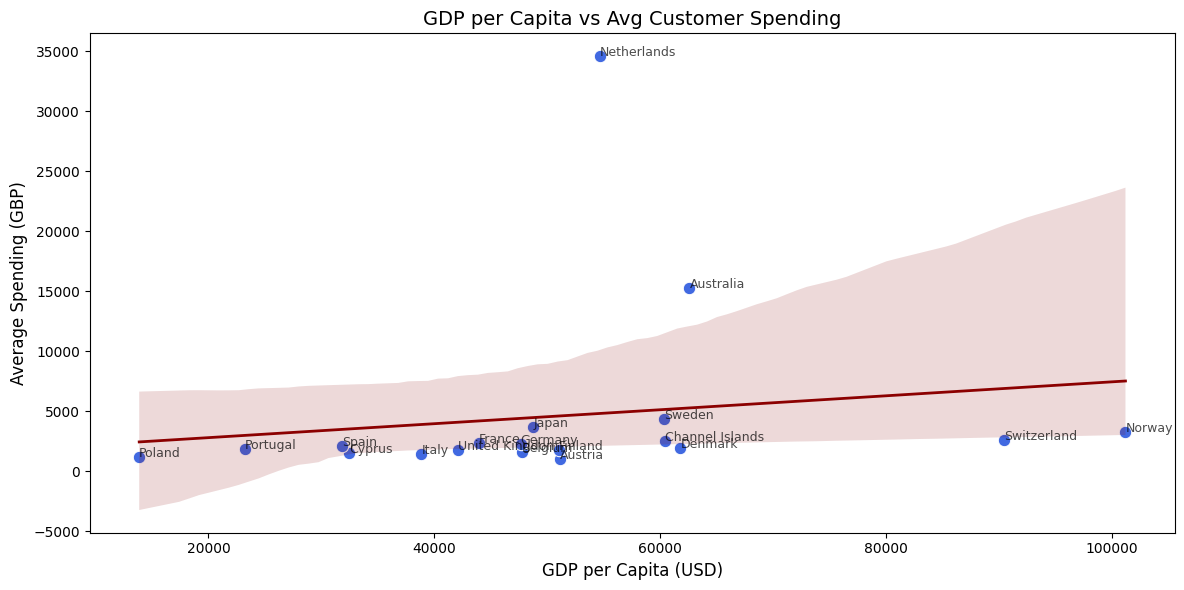

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=merged_df, x="GDP_per_capita", y="AvgSpendingPerCustomer", s=80, color="royalblue")
sns.regplot(data=merged_df, x="GDP_per_capita", y="AvgSpendingPerCustomer", scatter=False, color="darkred", line_kws={"linewidth": 2})
for i in range(len(merged_df)):
    plt.text(merged_df["GDP_per_capita"].iloc[i], merged_df["AvgSpendingPerCustomer"].iloc[i], merged_df["Country"].iloc[i], fontsize=9, alpha=0.7)
plt.title("GDP per Capita vs Avg Customer Spending", fontsize=14)
plt.xlabel("GDP per Capita (USD)", fontsize=12)
plt.ylabel("Average Spending (GBP)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
reg_model = smf.ols("AvgSpendingPerCustomer ~ GDP_per_capita + AvgNumPurchases", data=merged_df).fit()
print(reg_model.summary())

                              OLS Regression Results                              
Dep. Variable:     AvgSpendingPerCustomer   R-squared:                       0.857
Model:                                OLS   Adj. R-squared:                  0.839
Method:                     Least Squares   F-statistic:                     47.97
Date:                    Thu, 05 Jun 2025   Prob (F-statistic):           1.74e-07
Time:                            05:09:45   Log-Likelihood:                -178.50
No. Observations:                      19   AIC:                             363.0
Df Residuals:                          16   BIC:                             365.8
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
In

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


ADDITIONAL METRICS FOR DASHBOARD

In [ ]:
revenue_per_country = retail_df_clean.groupby("Country", as_index=False)["TotalPrice"].sum()
revenue_per_country.rename(columns={"TotalPrice": "TotalRevenue"}, inplace=True)

In [ ]:
avg_qty_per_order = retail_df_clean.groupby("Country", as_index=False)["Quantity"].mean()
avg_qty_per_order.rename(columns={"Quantity": "AvgQuantityPerOrder"}, inplace=True)

In [ ]:
unique_products_per_country = retail_df_clean.groupby("Country", as_index=False)["StockCode"].nunique()
unique_products_per_country.rename(columns={"StockCode": "UniqueProducts"}, inplace=True)

In [ ]:
merged_df = merged_df.merge(revenue_per_country, on="Country", how="left")
merged_df = merged_df.merge(avg_qty_per_order, on="Country", how="left")
merged_df = merged_df.merge(unique_products_per_country, on="Country", how="left")

In [ ]:
intercept = reg_model.params["Intercept"]
gdp_coef = reg_model.params["GDP_per_capita"]
purchase_coef = reg_model.params["AvgNumPurchases"]

In [ ]:
merged_df["PredictedSpending"] = (
    intercept + gdp_coef * merged_df["GDP_per_capita"] + purchase_coef * merged_df["AvgNumPurchases"]
)
merged_df["PredictedSpending"] = merged_df["PredictedSpending"].round(2)

In [ ]:
merged_df["GDP_Tier"] = pd.qcut(merged_df["GDP_per_capita"], q=4, labels=["1. Low", "2. Mid-Low", "3. Mid-High", "4. High"])

In [ ]:
actual_avg = merged_df.groupby("GDP_Tier")["AvgSpendingPerCustomer"].mean().reset_index()

<ipython-input-26-1bec5c5bfbb1>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  actual_avg = merged_df.groupby("GDP_Tier")["AvgSpendingPerCustomer"].mean().reset_index()


In [ ]:
tier_means = merged_df.groupby("GDP_Tier")[["GDP_per_capita", "AvgNumPurchases"]].mean().reset_index()
tier_means["PredictedSpending"] = reg_model.predict(tier_means)

<ipython-input-27-cc4195626186>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_means = merged_df.groupby("GDP_Tier")[["GDP_per_capita", "AvgNumPurchases"]].mean().reset_index()


In [ ]:
profile_plot_df = pd.merge(actual_avg, tier_means, on="GDP_Tier")

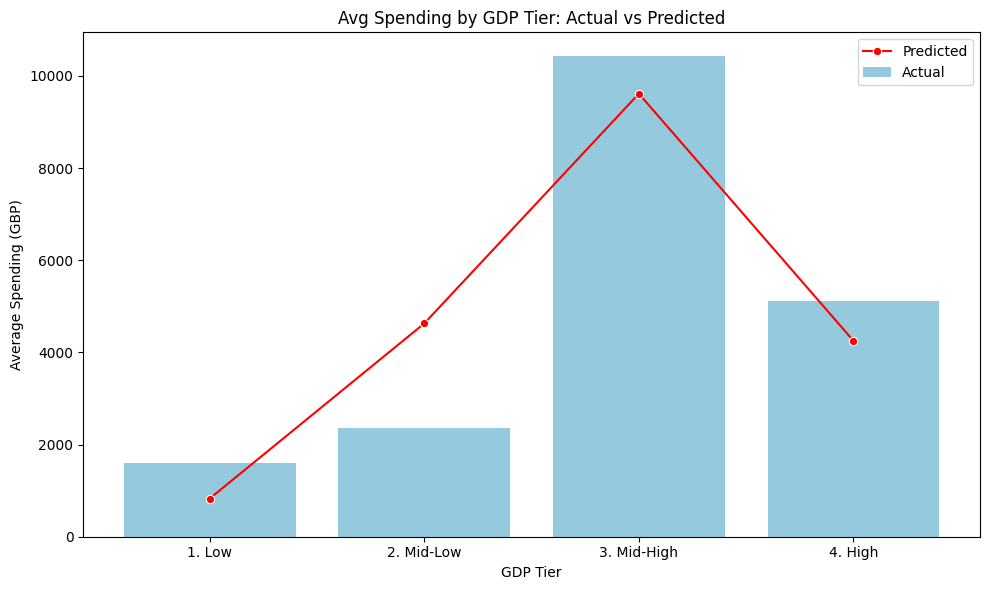

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=profile_plot_df, x="GDP_Tier", y="AvgSpendingPerCustomer", color="skyblue", label="Actual")
sns.lineplot(data=profile_plot_df, x="GDP_Tier", y="PredictedSpending", color="red", marker="o", label="Predicted")
plt.title("Avg Spending by GDP Tier: Actual vs Predicted")
plt.ylabel("Average Spending (GBP)")
plt.xlabel("GDP Tier")
plt.legend()
plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
avg_order_spending = retail_df_clean.groupby("Country", as_index=False)["TotalPrice"].mean()
avg_order_spending.rename(columns={"TotalPrice": "AvgSpendingPerOrder"}, inplace=True)

In [ ]:
cust_totals = (
    retail_df_clean
    .groupby("CustomerID")["TotalPrice"]
    .sum()
    .reset_index()
    .rename(columns={"TotalPrice":"TotalSpend"})
)

In [ ]:
cust_counts = (
    retail_df_clean
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo":"NumTx"})
)


In [ ]:
cust = pd.merge(cust_totals, cust_counts, on="CustomerID")
cust["AvgSpendingPerCustomer"] = cust["TotalSpend"] / cust["NumTx"]

In [ ]:
with pd.ExcelWriter(output_path) as writer:
    merged_df.to_excel(writer, sheet_name="Merged Country Summary", index=False)
    merged_df[["Country", "AvgSpendingPerCustomer"]].to_excel(writer, sheet_name="Avg Spending per Customer", index=False)
    avg_spending.to_excel(writer, sheet_name="Spending & Behavior", index=False)
    top10.to_excel(writer, sheet_name="Top10 Countries", index=False)
    pd.DataFrame([summary_stats]).to_excel(writer, sheet_name="Summary Stats", index=False)
    avg_order_spending.to_excel(writer, sheet_name="Avg Spending per Order", index=False)
    revenue_per_country.to_excel(writer, sheet_name="Total Revenue", index=False)
    avg_qty_per_order.to_excel(writer, sheet_name="Avg Quantity per Order", index=False)
    unique_products_per_country.to_excel(writer, sheet_name="Unique Products", index=False)
    profile_plot_df.to_excel(writer, sheet_name="Profile Plot Data", index=False)

In [ ]:
with pd.ExcelWriter(output_path, mode="a", if_sheet_exists="replace") as writer:
    profile_plot_df.to_excel(writer, sheet_name="Profile Plot Data", index=False)

In [ ]:
with pd.ExcelWriter(output_path, mode="a", engine="openpyxl") as writer:
    cust[["CustomerID","AvgSpendingPerCustomer"]]\
        .to_excel(writer,
                  sheet_name="Cust_Spend_Dist",
                  index=False)

# Google looker link:

https://lookerstudio.google.com/reporting/800a0432-9416-4f8a-b2f2-8637f28d6a91/page/1nqKF